In [2]:
import os
import time
import threading #tworzenie watkow
import subprocess

import psutil
import matplotlib.pyplot as plt

In [3]:
# zmienne globalne
cpu_usage = []
ram_usage = []
timestamps = []

monitoring = False

In [4]:
# monitor

def monitor_resources():

    start_time = time.time()

    while monitoring:

        cpu = psutil.cpu_percent(interval=1)
        ram = psutil.virtual_memory().percent

        cpu_usage.append(cpu)
        ram_usage.append(ram)
        timestamps.append(round(time.time() - start_time, 1))

        if ram > 80:
            print("Ostrzeżenie! Zużycie pamięci RAM przekroczyło 80%.")

Monitor ma działać równocześnie z wykonywaniem notebooka, stąd osobny wątek

In [5]:
# uruchomienie notebooka
def execute_notebook(notebook_name):

    global monitoring

    if not os.path.exists(notebook_name):
        print(f"Nie znaleziono pliku: {notebook_name}")
        return

    cpu_usage.clear()
    ram_usage.clear()
    timestamps.clear()

    monitoring = True

    monitor_thread = threading.Thread(target=monitor_resources)
    monitor_thread.start()

    print("Rozpoczynam wykonywanie notebooka...")

    subprocess.run([
        "jupyter",
        "nbconvert",
        "--to",
        "notebook",
        "--execute",
        notebook_name
    ])

    time.sleep(1)

    monitoring = False
    monitor_thread.join()

    print("Notebook został wykonany.")

In [6]:
# uruchomienie
execute_notebook("lesson02_practice.ipynb")

Rozpoczynam wykonywanie notebooka...


[NbConvertApp] Converting notebook lesson02_practice.ipynb to notebook
[NbConvertApp] Writing 5044 bytes to lesson02_practice.nbconvert.ipynb


Notebook został wykonany.


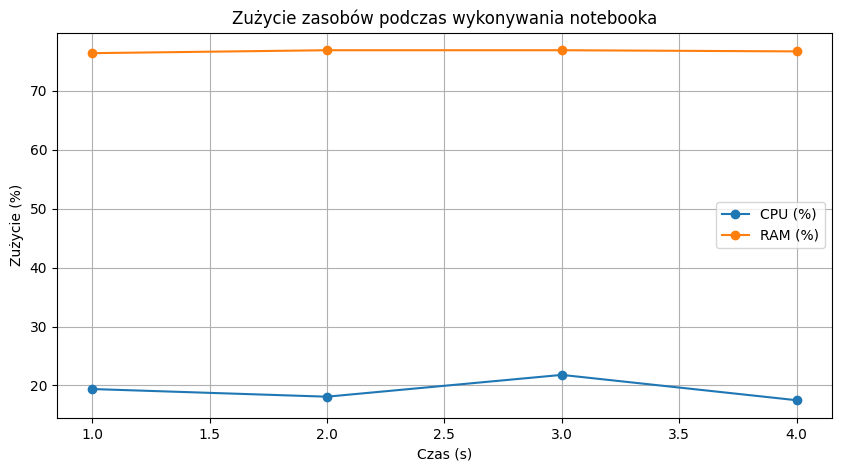

In [7]:
# wykres
plt.figure(figsize=(10,5))

plt.plot(
    timestamps,
    cpu_usage,
    marker="o",
    label="CPU (%)"
)

plt.plot(
    timestamps,
    ram_usage,
    marker="o",
    label="RAM (%)"
)

plt.title("Zużycie zasobów podczas wykonywania notebooka")
plt.xlabel("Czas (s)")
plt.ylabel("Zużycie (%)")

plt.grid(True)
plt.legend()

plt.savefig("resource_usage.png")

plt.show()

In [37]:
with open("resource_report.html", "w") as file:

    file.write("<html>")
    file.write("<head><title>Raport zasobów</title></head>")
    file.write("<body>")

    file.write("<h1>Raport wykorzystania zasobów</h1>")

    if cpu_usage and ram_usage:

        file.write(f"<p>Maksymalne użycie CPU: {max(cpu_usage):.1f}%</p>")
        file.write(f"<p>Maksymalne użycie RAM: {max(ram_usage):.1f}%</p>")

    else:

        file.write("<p>Brak danych do wygenerowania raportu.</p>")

    file.write("<h2>Wykres</h2>")
    file.write('<img src="resource_usage.png" width="700">')

    file.write("</body>")
    file.write("</html>")

print("Raport został zapisany jako resource_report.html")

Raport został zapisany jako resource_report.html
